# GIS Density Estimation Quality
[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/rbig/blob/main/docs/notebooks/16_gis_density_estimation.ipynb)

A fitted `GIS` model is a normalizing flow, so `score_samples(X)` returns
an exact log-density under the model via the change-of-variables formula.
To judge how *good* that density is, we need targets whose true density is
known in closed form. This notebook:

- fits GIS on **Gaussian mixtures** with known densities,
- compares `score_samples` against the true log-density pointwise,
- visualizes density **contours** (2D) and **slices**, and
- quantifies the error with a Monte-Carlo **KL divergence** estimate.

> **Colab / fresh environment?** Run the cell below to install `rbig` from
> GitHub. Skip if already installed.

In [ ]:
!pip install "rbig[all] @ git+https://github.com/jejjohnson/rbig.git" -q

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

from rbig import GIS

plt.style.use("seaborn-v0_8-paper")

/home/user/rbig/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Ground-Truth Target: 2D Gaussian Mixture

Three well-separated components with anisotropic covariances — multi-modal
*and* correlated, but with an exact `logpdf`.

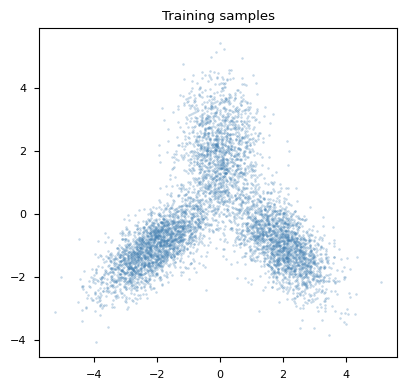

In [3]:
class GaussianMixture2D:
    """A fixed 3-component 2D GMM with exact density and sampling."""

    def __init__(self):
        self.weights = np.array([0.4, 0.35, 0.25])
        self.means = np.array([[-2.0, -1.0], [2.0, -1.0], [0.0, 2.0]])
        self.covs = np.array(
            [
                [[0.8, 0.5], [0.5, 0.6]],
                [[0.6, -0.4], [-0.4, 0.7]],
                [[0.4, 0.0], [0.0, 1.2]],
            ]
        )
        self._components = [
            stats.multivariate_normal(mean=m, cov=c)
            for m, c in zip(self.means, self.covs)
        ]

    def sample(self, n: int, seed: int = 0) -> np.ndarray:
        rng = np.random.default_rng(seed)
        labels = rng.choice(len(self.weights), size=n, p=self.weights)
        out = np.empty((n, 2))
        for k, comp in enumerate(self._components):
            mask = labels == k
            out[mask] = comp.rvs(size=int(mask.sum()), random_state=rng)
        return out

    def logpdf(self, X: np.ndarray) -> np.ndarray:
        # log sum_k w_k N(x; mu_k, C_k), computed stably.
        comp_logs = np.stack(
            [np.log(w) + c.logpdf(X) for w, c in zip(self.weights, self._components)],
            axis=0,
        )
        m = comp_logs.max(axis=0)
        return m + np.log(np.exp(comp_logs - m).sum(axis=0))


target = GaussianMixture2D()
X_train = target.sample(6_000, seed=0)
X_test = target.sample(6_000, seed=1)

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(X_train[:, 0], X_train[:, 1], s=2, alpha=0.3, color="steelblue")
ax.set_title("Training samples")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## Fit GIS

In [4]:
model = GIS(n_layers=100, random_state=0).fit(X_train)
print(f"{model.n_layers_} layers kept")
print(f"train mean LL: {model.score(X_train):.3f} nats")
print(f"test  mean LL: {model.score(X_test):.3f} nats")
print(f"true  mean LL: {np.mean(target.logpdf(X_test)):.3f} nats (entropy bound)")

8 layers kept
train mean LL: -3.233 nats
test  mean LL: -3.227 nats
true  mean LL: -3.171 nats (entropy bound)


The model's held-out log-likelihood should approach — but never exceed, in
expectation — the true expected log-density $-H(p)$.

## Density Contours: True vs Estimated

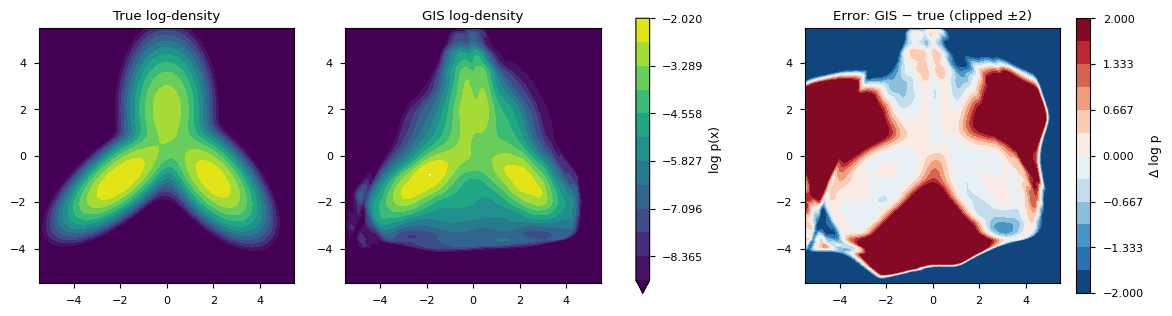

In [5]:
grid = np.linspace(-5.5, 5.5, 220)
GX, GY = np.meshgrid(grid, grid)
P = np.stack([GX.ravel(), GY.ravel()], axis=1)  # P: (220*220, 2)

log_p_true = target.logpdf(P).reshape(GX.shape)
log_p_gis = model.score_samples(P).reshape(GX.shape)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
levels = np.linspace(-9, np.max(log_p_true), 12)
for ax, Z, title in [
    (axes[0], log_p_true, "True log-density"),
    (axes[1], log_p_gis, "GIS log-density"),
]:
    cs = ax.contourf(GX, GY, Z, levels=levels, cmap="viridis", extend="min")
    ax.set_title(title)
    ax.set_aspect("equal")
fig.colorbar(cs, ax=axes[:2], shrink=0.85, label="log p(x)")

err = log_p_gis - log_p_true
im = axes[2].contourf(
    GX, GY, np.clip(err, -2, 2), levels=np.linspace(-2, 2, 13), cmap="RdBu_r"
)
axes[2].set_title("Error: GIS − true (clipped ±2)")
axes[2].set_aspect("equal")
fig.colorbar(im, ax=axes[2], shrink=0.85, label="Δ log p")
plt.show()

The mixture's modes, anisotropy, and mode weights are all recovered. The
largest errors sit in the near-zero-density regions *between* and *around*
the modes, where training data is scarce — a generic feature of
sample-based density estimators.

## Density Slices

1D slices through the density surface make the tail behavior visible.

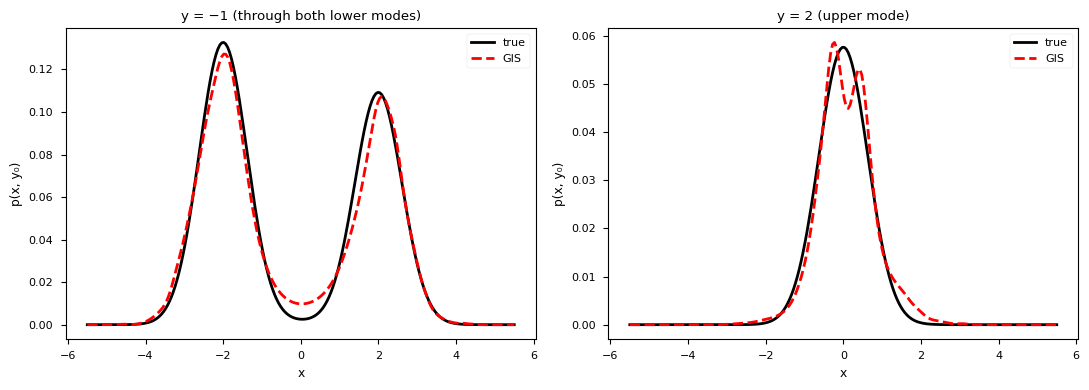

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
slice_specs = [(-1.0, "y = −1 (through both lower modes)"), (2.0, "y = 2 (upper mode)")]
for ax, (y0, title) in zip(axes, slice_specs):
    line = np.stack([grid, np.full_like(grid, y0)], axis=1)
    ax.plot(grid, np.exp(target.logpdf(line)), "k-", lw=2, label="true")
    ax.plot(grid, np.exp(model.score_samples(line)), "r--", lw=2, label="GIS")
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("p(x, y₀)")
    ax.legend()
plt.tight_layout()
plt.show()

## Pointwise Agreement and KL Divergence

On held-out samples (i.e. weighted by where the density actually lives),
the pointwise log-densities should agree tightly, and a Monte-Carlo
estimate of the forward KL divergence

$$D_\mathrm{KL}(p \,\|\, \hat p) = \mathbb{E}_{x \sim p}\big[\log p(x) - \log \hat p(x)\big]$$

summarizes the remaining error in nats.

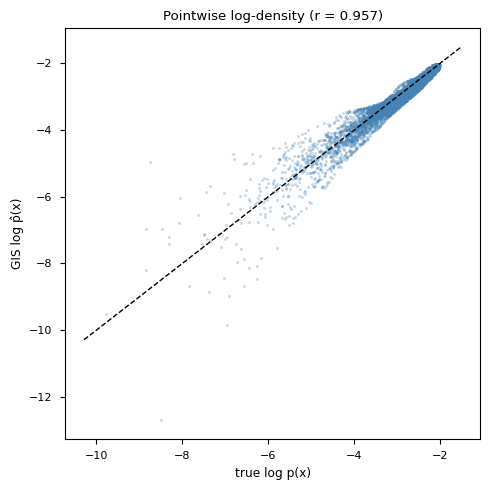

KL(p || p̂) ≈ 0.0560 ± 0.0033 nats   (0 = perfect)
pointwise correlation: 0.9572


In [7]:
lp_true = target.logpdf(X_test)
lp_gis = model.score_samples(X_test)

kl = np.mean(lp_true - lp_gis)
se = np.std(lp_true - lp_gis) / np.sqrt(X_test.shape[0])
corr = np.corrcoef(lp_true, lp_gis)[0, 1]

fig, ax = plt.subplots(figsize=(5, 5))
lims = [np.min(lp_true) - 0.5, np.max(lp_true) + 0.5]
ax.scatter(lp_true, lp_gis, s=3, alpha=0.3, color="steelblue")
ax.plot(lims, lims, "k--", lw=1)
ax.set_xlabel("true log p(x)")
ax.set_ylabel("GIS log p̂(x)")
ax.set_title(f"Pointwise log-density (r = {corr:.3f})")
plt.tight_layout()
plt.show()

print(f"KL(p || p̂) ≈ {kl:.4f} ± {se:.4f} nats   (0 = perfect)")
print(f"pointwise correlation: {corr:.4f}")

## A Harder Case: 5D Mixture

The same protocol in 5D — two anisotropic Gaussian components.

In [8]:
rng = np.random.default_rng(7)
d = 5
mu1, mu2 = np.full(d, -1.2), np.full(d, 1.2)
A1, A2 = rng.standard_normal((d, d)) * 0.3, rng.standard_normal((d, d)) * 0.3
C1, C2 = A1 @ A1.T + 0.5 * np.eye(d), A2 @ A2.T + 0.5 * np.eye(d)
w = 0.5
comp1 = stats.multivariate_normal(mu1, C1)
comp2 = stats.multivariate_normal(mu2, C2)


def sample_5d(n: int, seed: int) -> np.ndarray:
    rng = np.random.default_rng(seed)
    labels = rng.random(n) < w
    out = np.where(
        labels[:, None],
        comp1.rvs(size=n, random_state=rng),
        comp2.rvs(size=n, random_state=rng),
    )
    return out


def logpdf_5d(X: np.ndarray) -> np.ndarray:
    la = np.log(w) + comp1.logpdf(X)
    lb = np.log(1 - w) + comp2.logpdf(X)
    m = np.maximum(la, lb)
    return m + np.log(np.exp(la - m) + np.exp(lb - m))


X5_train, X5_test = sample_5d(6_000, seed=2), sample_5d(6_000, seed=3)
model5 = GIS(n_layers=100, random_state=0).fit(X5_train)

lp_true5 = logpdf_5d(X5_test)
lp_gis5 = model5.score_samples(X5_test)
kl5 = np.mean(lp_true5 - lp_gis5)
se5 = np.std(lp_true5 - lp_gis5) / np.sqrt(X5_test.shape[0])
print(f"5D: {model5.n_layers_} layers kept")
print(f"5D: test mean LL = {np.mean(lp_gis5):.3f} vs true {np.mean(lp_true5):.3f} nats")
print(f"5D: KL(p || p̂) ≈ {kl5:.4f} ± {se5:.4f} nats")

5D: 13 layers kept
5D: test mean LL = -7.357 vs true -7.283 nats
5D: KL(p || p̂) ≈ 0.0736 ± 0.0084 nats


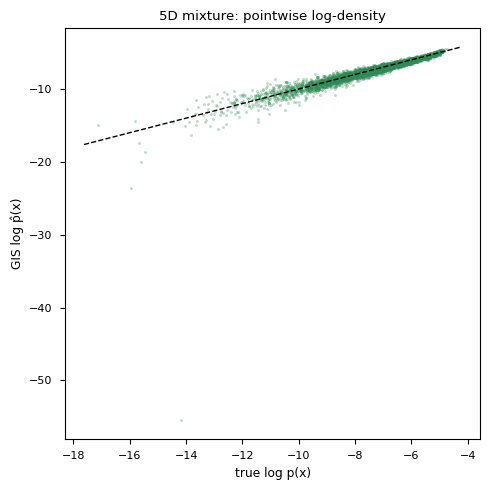

In [9]:
fig, ax = plt.subplots(figsize=(5, 5))
lims = [np.min(lp_true5) - 0.5, np.max(lp_true5) + 0.5]
ax.scatter(lp_true5, lp_gis5, s=3, alpha=0.3, color="seagreen")
ax.plot(lims, lims, "k--", lw=1)
ax.set_xlabel("true log p(x)")
ax.set_ylabel("GIS log p̂(x)")
ax.set_title("5D mixture: pointwise log-density")
plt.tight_layout()
plt.show()

---
## Summary

- `GIS.score_samples` recovers multi-modal, anisotropic densities: modes,
  weights, and covariance structure all match the ground truth.
- Errors concentrate in low-density regions where training data is scarce;
  on held-out samples the pointwise agreement is tight.
- The forward KL divergence — the gap between the true expected
  log-density and the model's held-out log-likelihood — is a fraction of a
  nat on these targets, in both 2D and 5D.

## See Also

- [Theory — RBIG vs SIG/GIS](../notes/sliced_iterative_gaussianization.md)
- [GIS Demo](14_sliced_gaussianization.ipynb)
- [Sampling Quality](17_sig_sampling_quality.ipynb)
- [Boundary Behavior](18_sig_boundary_behavior.ipynb)